In [1]:
import cv2
import numpy as np
import pandas as pd
from plotnine import *
from scipy.spatial import KDTree
from scipy.stats import zscore
import math

In [2]:
files_path = "tree_mapper/maps"

In [3]:
# https://www.geeksforgeeks.org/python/circle-detection-using-opencv-python/
# Read image
images = ["/turtlebot_area.pgm", "/ulthwe_static_map.pgm", "/urukhai_dynamic_map.pgm", "/testing.pgm"]
img = cv2.imread(files_path + images[3], cv2.IMREAD_GRAYSCALE)
output = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

# Circle detection

In [191]:
def convert_parameters_to_pixels(parameters: list):
    resolution = 0.04 #meters per pixel
    newParams = []
    for p in parameters:
        newParams.append(int(p * 1/resolution))
    return newParams
    
    #0.04m/p * p = m
    #1/0.04(m/p) = 1/0.04 p/m

params = (20, 6, 9)
params = (.3, 0, .15)

p2 = convert_parameters_to_pixels(params)
print(p2)

params = {'minDist': p2[0],'minRadius':  p2[1], 'maxRadius' : p2[2]}


[7, 0, 3]


In [219]:
# Detect circles
circles = cv2.HoughCircles(
    img,
    cv2.HOUGH_GRADIENT,
    dp=4,
    minDist=params['minDist'],
    param1=10,         
    param2=10,       
    minRadius=params['minRadius'],       
    maxRadius=params['maxRadius']
)

In [223]:
circles[0][0][0]

np.float32(42.0)

In [220]:
# Draw only the first detected circle
if circles is not None:
    print(circles)
    for row in circles:
        print(row)
        for x, y, r in row:
            cv2.circle(output, (x, y), r, (0, 255, 0), 1)  # Circle outline
            cv2.circle(output, (x, y), 1, (0, 0, 255), 1)  # Center point


[[[ 42.  126.    1.2]
  [222.    6.    1.2]
  [ 62.  110.    1.2]
  [ 74.   62.    1.2]
  [ 26.  122.    1.2]
  [ 90.  106.    1.2]
  [106.   10.    1.2]
  [110.  142.    1.2]
  [182.  146.    1.2]
  [202.  130.    1.2]
  [226.   94.    1.2]
  [230.   30.    1.2]
  [  6.   66.    1.2]
  [ 50.  114.    1.2]
  [ 54.   10.    1.2]
  [ 58.   62.    1.2]
  [ 70.  110.    1.2]
  [ 70.  126.    1.2]
  [ 78.   14.    1.2]
  [ 98.  142.    1.2]
  [138.  102.    1.2]
  [178.  134.    1.2]
  [202.   66.    1.2]
  [210.    6.    1.2]
  [226.   58.    1.2]
  [ 10.   50.    1.2]
  [ 14.   86.    1.2]
  [ 18.   66.    1.2]
  [ 22.   58.    1.2]
  [ 38.   82.    1.2]
  [ 42.   66.    1.2]
  [ 46.  138.    1.2]
  [ 50.   38.    1.2]
  [ 58.  134.    1.2]
  [ 62.   78.    1.2]
  [ 82.  110.    1.2]
  [ 86.   74.    1.2]
  [102.   78.    1.2]
  [118.  118.    1.2]
  [122.   14.    1.2]
  [158.  106.    1.2]
  [170.  126.    1.2]
  [254.  130.    1.2]]]
[[ 42.  126.    1.2]
 [222.    6.    1.2]
 [ 62.  11

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'circle'
> Overload resolution failed:
>  - Can't parse 'center'. Sequence item with index 0 has a wrong type
>  - Can't parse 'center'. Sequence item with index 0 has a wrong type


In [29]:
scale = 3
# Show result
scaled_output = cv2.resize(output, dsize=None, fx=scale,fy=scale, interpolation=cv2.INTER_NEAREST)
# cv2.namedWindow("Detected Circles", cv2.WINDOW_NORMAL)
# cv2.resizeWindow("Detected Circles", 600, 600)
cv2.imshow('Detected Circles', scaled_output)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Alternatives

In [ ]:
img2 = img.copy()
output2 = output.copy()

ret, thresh = cv2.threshold(img2, 127, 255, cv2.THRESH_BINARY_INV)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

cnts = contours
if not isinstance(cnts, tuple):
    cnts = [cnts]
# epsilon = 0.1*cv2.arcLength(cnt,True)

# approx = cv2.approxPolyDP(cnt,epsilon,True)

filtered_cnts = []
trees = []
for c in cnts:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, peri, True)
    area = cv2.contourArea(c)

    (x,y), radius = cv2.minEnclosingCircle(c)
    # filtered_cnts.append((peri, len(approx), area, x, y, radius))

    if (len(approx) > 0 and
        #area = 0 only for single points.
        area > 0 and area < 5
        and radius < 3
        and peri > 2 and peri < 10):
        # cv2.circle(output2, (int(x), int(y)), int(radius), (0, 255, 0), 1)
        trees.append((x, y, radius))
        filtered_cnts.append((peri, len(approx), area, x, y, radius))

# Draw only the first detected circle
trees = [trees]
if trees is not None:
    trees = np.uint16(np.around(trees))
    for row in trees:
        for x, y, r in row:
            cv2.circle(output2, (x, y), 0, (0, 255, 0), 1)  # Circle outline
            cv2.circle(output2, (x, y), 1, (0, 0, 255), 1)  # Center point

scale = 2
# Show result
scaled_output = cv2.resize(output2, dsize=None, fx=scale,fy=scale, interpolation=cv2.INTER_NEAREST)
# cv2.namedWindow("Detected Circles", cv2.WINDOW_NORMAL)
# cv2.resizeWindow("Detected Circles", 600, 600)
cv2.imshow('Detected Circles', scaled_output)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [246]:
circles_scaled = trees * 0.04
print(trees)
circles_translated = []
for circle in circles_scaled:
    for x, y, r in circle:
        x_meters = x + 1
        y_meters = y + 1
        r_meters = r
        circles_translated.append((x_meters, y_meters, r_meters))

[[[182 146   2]
  [231 137   1]
  [188 134   1]
  [130 134   1]
  [102 131   1]
  [ 98 130   2]
  [199 124   1]
  [205  62   1]
  [188  60   1]
  [172  58   1]
  [207  44   1]
  [190  42   1]
  [174  40   1]
  [100   8   2]]]


In [137]:
def insert(q, d):
    q.append(d)

def delete(q):
    try:
        m = 0
        for i in range(len(q)):
            if q[i][1] > q[m][1]:
                m = i
        item = q[m]
        del q[m]
        return item
    except IndexError:
        return 0
        print("Queue empty.")
        exit()

def is_empty(q):
    return len(q) == 0

In [206]:
output3 = output.copy()

print(f"start: {len(trees)}")
tree_kd = KDTree(trees)
neighbour_points = tree_kd.query_ball_tree(tree_kd, 23)
too_close_points = tree_kd.query_ball_tree(tree_kd, 10)

# i, goldilocks neighbour count, nn angle 1, nn angle 2.
def compute_node_data(trees):

    potential_grid_points = {}
    for i in range(len(trees)):
        goldilocks_points = set(neighbour_points[i]) - set(too_close_points[i])
        
        if len(goldilocks_points) < 2:
            print("point is waaay too lonely")
            continue
        potential_grid_points[i] = goldilocks_points

    print(f"after goldilocks: {len(potential_grid_points)}")

    filtered_potential_points = {}
    for key in potential_grid_points.keys():
        x, y = trees[key]

        neighbours = potential_grid_points[key]
        neighbours_PQ = []
        for i in neighbours:
            if i not in potential_grid_points.keys():
                continue
            
            x2, y2 = trees[i]

            d = math.sqrt((x - x2)**2 + (y-y2)**2)
            insert(neighbours_PQ, [i, d])
        
        if len(neighbours_PQ) < 2:
            print("point is lonely")
            continue
        
        # Source - https://stackoverflow.com/a/35178910
        # Posted by Eric
        # Retrieved 2026-05-27, License - CC BY-SA 3.0

        a = trees[delete(neighbours_PQ)[0]]
        c = trees[delete(neighbours_PQ)[0]]
        a = np.array(a)
        b = np.array([x, y])
        c = np.array(c)

        ba = a - b
        bc = c - b

        cosine_ratio = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
        angle = np.degrees(np.arccos(cosine_ratio))
        
        if value > 30:
            print("point's angle sucks")
            continue

        filtered_potential_points[key] = value
        # cv2.circle(output3, (int(x), int(y)), int(20), (0, 255, 0), 1)
        # cv2.circle(output3, (int(x), int(y)), int(10), (255, 0, 0), 1)

    print(f"after goldilocks neighbours: {len(filtered_potential_points)}")

    return potential_grid_points, filtered_potential_points

f_pot, first_points = filter_angles(trees)
first_i = list(first_points.keys())
fPotI = list(f_pot.keys())

first_pass = [trees[i] for i in first_i]

s_pot, second_points = filter_angles(first_pass)
second_i = [first_i[i] for i in list(second_points.keys())]
sPotI = [first_i[i] for i in list(s_pot.keys())]

values = list(second_points.values())
    

#abs to identify outliers regardless of direction.
z_scores = abs(zscore(values))

z_score_dict = {
    key: z
    for key, z in zip(filtered_potential_points.keys(), z_scores)
}

k = 6
most_likely_6_trees = sorted(z_score_dict, key=z_score_dict.get)[:k]

print(f"after zscore filtering: {len(most_likely_6_trees)}")


for i in fPotI:
    x, y = trees[i]
    cv2.circle(output3, (int(x), int(y)), int(20), (0, 255, 0), 1)
    cv2.circle(output3, (int(x), int(y)), int(10), (255, 0, 0), 1)
    cv2.circle(output3, (int(x), int(y)), int(0), (0, 0, 255), 1)


scale = 3
# Show result
scaled_output = cv2.resize(output3, dsize=None, fx=scale,fy=scale, interpolation=cv2.INTER_NEAREST)
# cv2.namedWindow("Detected Circles", cv2.WINDOW_NORMAL)
# cv2.resizeWindow("Detected Circles", 600, 600)
cv2.imshow('Detected Circles', scaled_output)
cv2.waitKey(0)
cv2.destroyAllWindows()


start: 14
start: 14
point is waaay too lonely
point is waaay too lonely
point is waaay too lonely
point is waaay too lonely
point is waaay too lonely
point is waaay too lonely
point is waaay too lonely
after goldilocks: 7


ValueError: too many values to unpack (expected 2, got 3)

In [174]:
output3 = output.copy()

cnts = cv2.goodFeaturesToTrack(output3, 4,3, 20)
cv2.drawContours(output3, cnts, -1, (0,255,0), 1)
scale = 3
# Show result
scaled_output = cv2.resize(output3, dsize=None, fx=scale,fy=scale, interpolation=cv2.INTER_NEAREST)
# cv2.namedWindow("Detected Circles", cv2.WINDOW_NORMAL)
# cv2.resizeWindow("Detected Circles", 600, 600)
cv2.imshow('Detected Circles', scaled_output)
cv2.waitKey(0)
cv2.destroyAllWindows()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\corner.cpp:254: error: (-215:Assertion failed) src.type() == CV_8UC1 || src.type() == CV_32FC1 in function 'cv::cornerEigenValsVecs'


In [ ]:
                    # if angle is
                    # close to 90, 180, 270 or 360.
value = min(abs(angle%90-90), abs(angle))

In [ ]:
import random

import numpy as np
from scipy.spatial import KDTree


def fit_lattice_ransac(
    points: np.ndarray,
    iterations: int = 500,
    tolerance: float = 0.25,
):

    best_inliers = []
    best_model = None

    tree = KDTree(points)

    for _ in range(iterations):

        # Pick random origin
        origin_idx = random.randint(0, len(points) - 1)
        origin = points[origin_idx]

        # Get nearby points
        _, idxs = tree.query(origin, k=min(8, len(points)))

        # Pick two random neighbors
        a_idx, b_idx = random.sample(list(idxs[1:]), 2)

        # Basis vectors
        u = points[a_idx] - origin
        v = points[b_idx] - origin

        # Build basis matrix
        basis = np.column_stack((u, v))

        # Convert world -> lattice coordinates
        inv_basis = np.linalg.inv(basis)

        inliers = []

        for point in points:

            relative = point - origin

            lattice = inv_basis @ relative

            i = lattice[0]
            j = lattice[1]

            # Distance from nearest integer lattice point
            err_i = abs(i - round(i))
            err_j = abs(j - round(j))

            if err_i < tolerance and err_j < tolerance:
                inliers.append(point)

        # Keep best lattice
        if len(inliers) > len(best_inliers):

            best_inliers = inliers

            best_model = {
                "origin": origin,
                "u": u,
                "v": v,
            }

    return np.array(best_inliers), best_model

# opencv circle grid detection

In [ ]:
# output3 = output.copy()
# img_scale = 8
# scaled_img = cv2.resize(img, dsize=None, fx=img_scale,fy=img_scale, interpolation=cv2.INTER_NEAREST)


# # Setup SimpleBlobDetector parameters.
# blobParams = cv2.SimpleBlobDetector_Params()

# # Change thresholds
# blobParams.minThreshold = 8
# blobParams.maxThreshold = 255

# # Filter by Area.
# blobParams.filterByArea = True
# blobParams.minArea = 0.1     # minArea may be adjusted to suit for your experiment
# blobParams.maxArea = 10   # maxArea may be adjusted to suit for your experiment

# # Filter by Circularity
# blobParams.filterByCircularity = False
# blobParams.minCircularity = 0.1

# # Filter by Convexity
# blobParams.filterByConvexity = False
# blobParams.minConvexity = 0.87

# # Filter by Inertia
# blobParams.filterByInertia = False
# blobParams.minInertiaRatio = 0.01

# # Create a detector with the parameters
# blobDetector = cv2.SimpleBlobDetector_create(blobParams)

# detector = cv2.SimpleBlobDetector_create(blob_params)

# finder_params = cv2.CirclesGridFinderParameters()

# finder_params.densityNeighborhoodSize = (60, 60)
# finder_params.minDensity = 3
# finder_params.minDistanceToAddKeypoint = 1
# finder_params.keypointScale = 1
# finder_params.minGraphConfidence = 0.0001
# finder_params.squareSize = 17
# finder_params.maxRectifiedDistance = 1000000

# cv2.CALIB_CB_SYMMETRIC_GRID
# found, centers = cv2.findCirclesGrid(
#     img,
#     patternSize=(2, 3),
#     flags=cv2.CALIB_CB_ASYMMETRIC_GRID,
#     blobDetector=detector,
#     parameters=finder_params,
# )

# print(f"found: {found}, centers: {centers}")


# if centers is not None:
#     for [[x, y]] in centers:
#         cv2.circle(output3, (int(x), int(y)), int(2), (0, 255, 0), 1)
# scale = 3
# # Show result
# scaled_output = cv2.resize(output3, dsize=None, fx=scale,fy=scale, interpolation=cv2.INTER_NEAREST)
# # cv2.namedWindow("Detected Circles", cv2.WINDOW_NORMAL)
# # cv2.resizeWindow("Detected Circles", 600, 600)
# cv2.imshow('Detected Circles', scaled_output)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

found: False, centers: [[[ 40.05525   37.425415]]

 [[ 26.        83.      ]]

 [[ 30.458015 148.54962 ]]]


In [65]:
df = pd.DataFrame(filtered_cnts, columns = ("peri", "approx", "area", "x", "y", "radius"))
df.describe()

,peri,approx,area,x,y,radius
count,14.000000,14.0,14.000000,14.000000,14.000000,14.000000
mean,5.912111,1.0,0.857143,169.107143,89.178571,1.266956
std,1.859102,0.0,0.363137,43.663565,48.024276,0.395267
min,3.414214,1.0,0.500000,98.000000,8.500000,0.707207
25%,4.828427,1.0,0.500000,140.625000,47.125000,1.118134
50%,5.414214,1.0,1.000000,185.000000,92.500000,1.118134
75%,6.681980,1.0,1.000000,196.875000,132.875000,1.414314
max,9.071068,1.0,1.500000,231.000000,146.000000,2.061653


# Rectangle testing

In [ ]:
line_tolerance = 1
length_tolerance = 1

#                           y = mx + c4
#                               \/
#                   (x3, y3)----___
#    y = m2x + c2 >   /             -----(x4, y4)
#                    /                     /   < y = m2x + c3
#                (x1,y1)----___           /
#                                -----(x2,y2)
#                              /\
#                           y = mx + c
# 
#
for i in range(len(trees)):
    x1, y1 = trees[i]
    for j in range(len(trees), 0, -1):     
        # start is inclusive, end is exclusive, so this corrects that.
        j -=1   
        if i==j:
            break
        x2, y2 = trees[j]

        sideLength = (y1 - y2)**2 + (x1 - x2)**2

        if (y1-y2) < 0.001 or (x1 - x2) < 0.001: # if the line is aligned with the axies.
            continue
        m = (y1-y2)/(x1 - x2)
        c = y1 - m*x1

        m2 = -1/m
        c2 = y2 - m2*x2 
        c3 = y1 - m2

        perpToFirst = -1
        perpToSecond = -1
        sideLength = -1
        for k in range(len(trees)):
            if k == j or k == i:
                continue
            
            if is_perpendicular(m2, c, trees[k]):
            x3, y3 = trees[k]

            #find all points perpendicular to both points.
            # if any point perpendicular to the first is equidistant to a point
            # perpendicular to the second, this is a rectangle.
            

            # perpendicular to second point point
            if m2*x3 + c2 - y3 < line_tolerance:
                perpToSecond = k

In [ ]:
def is_perpendicular(m, c, x, line_tolerance):
    if abs(m2*x3 + c3 - y3) < line_tolerance:
                distance = (y1 - y3)**2 + (x1 - x3)**2
                
                #if this is the first perpendicular point found
                if perpToSecond != -1:
                    perpToFirst = k
                    sideLength = distance
                    

                elif abs(sideLength - distance) < length_tolerance:
                    # at this point, we know the point is perpendicular,
                    #  and the right distance, but there are two points that meet this definition.


                    print("rectangle found!!!!")
                    break


In [ ]:
#       |
#   4   |   1   
# --------------
#   3   |   2
#       |

# if on the boundry, things don't work.
def get_quadrant(x, y):
    if x > 0:
        if y > 0:
            return 1
        else:
            return 2
    if x < 0:
        if y > 0:
            return 4
        else:
            return 3

# plotting

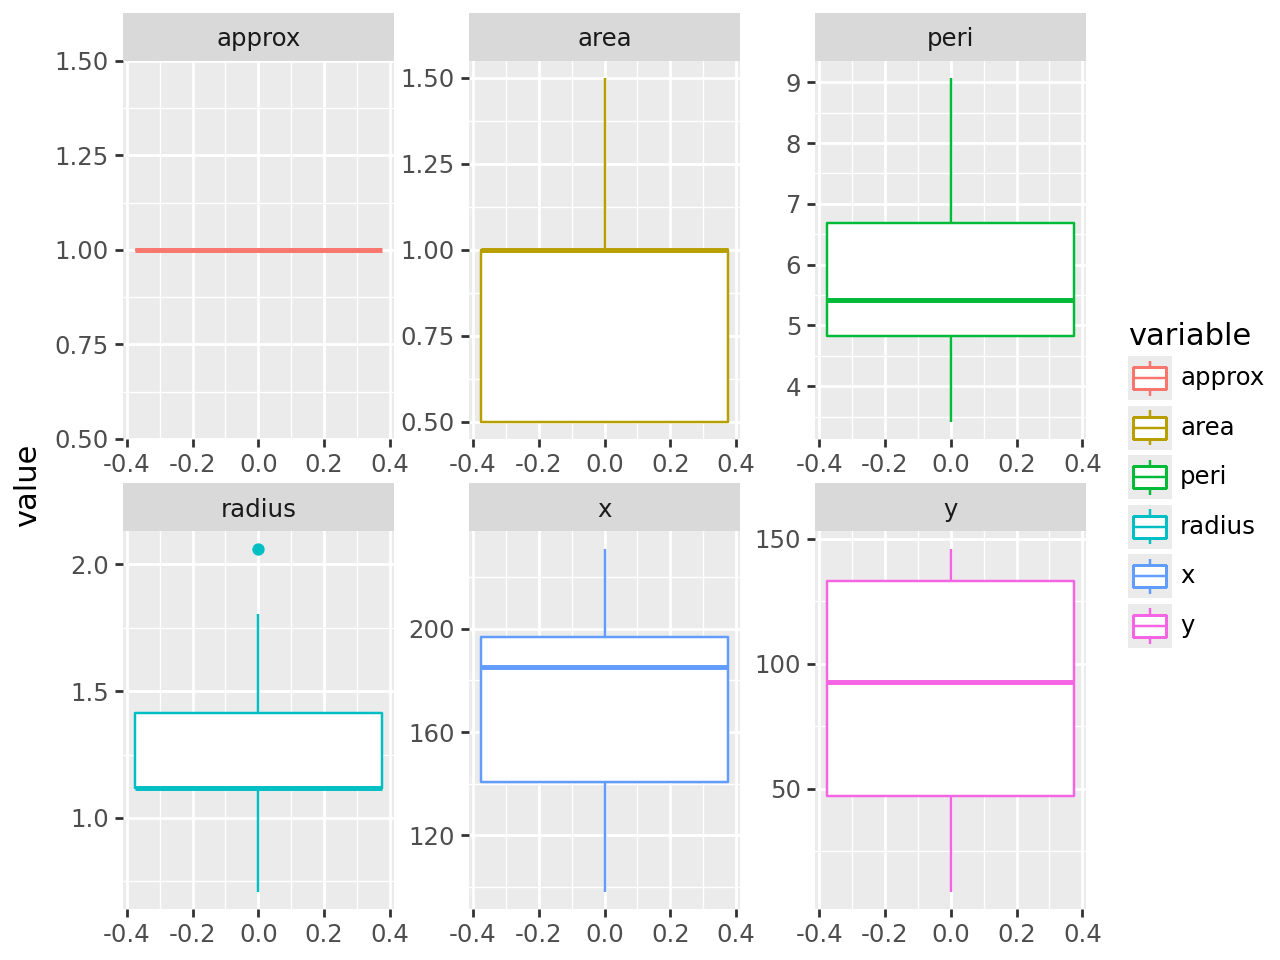

In [61]:
(
    ggplot(df.melt(), aes(y="value", color="variable"))
     + geom_boxplot() + facet_wrap("variable", ncol=3, scales="free")
     )

In [ ]:
# print(list(potential_grid_points.keys()))
# trees
# potential_grid_points
# filtered_potential_points
# most_likely_6_trees

trees_df = pd.DataFrame(trees, columns = ["x", "y"])

plot_df = trees_df.iloc[list(true_i)]

plot_df["angle"] = list(second_points.values())


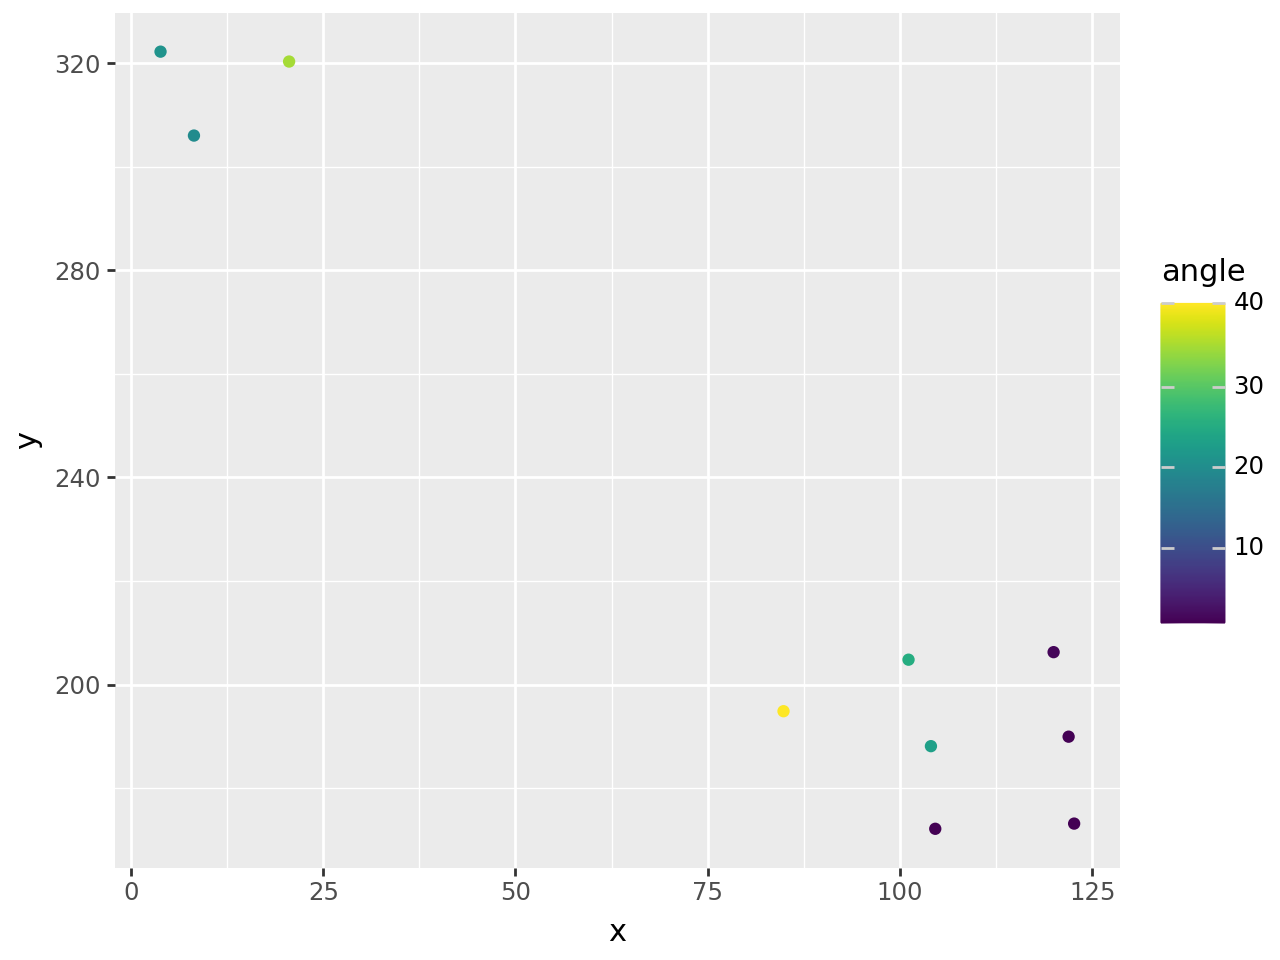

In [123]:
ggplot(plot_df, aes(x="x", y="y", color="angle")) + geom_point(position = "jitter")

In [124]:
plot_df.head(20)

,x,y,angle
1,4.000000,322.000000,20.947471
2,20.500000,320.000000,34.849073
6,8.000000,306.000000,19.499905
9,120.000000,206.500000,1.127724
11,101.500000,204.500000,25.048228
13,85.000000,194.500000,40.194687
14,121.500000,189.500000,0.726439
15,103.833336,188.166672,22.902922
17,123.000000,173.500000,0.592183
18,105.000000,172.000000,0.636060
